<a href="https://colab.research.google.com/github/juliamonjardim/time-series-electricity-forecasting/blob/main/TSA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv("Electric_Production.csv", index_col= "DATE", parse_dates=True)

In [38]:
# Now I'll do some EDA to inspect the data
data.head()

,Value
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


In [ ]:
data.tail()

,Value
DATE,
2017-09-01,98.6154
2017-10-01,93.6137
2017-11-01,97.3359
2017-12-01,114.7212
2018-01-01,129.4048


In [ ]:
# Getting numerical summary from dataset
data.describe()

,Value
count,397.000000
mean,88.847218
std,15.387834
min,55.315100
25%,77.105200
50%,89.779500
75%,100.524400
max,129.404800


In [39]:
# Starting to prepare data to visualize the time series
import matplotlib
matplotlib.rc("figure", figsize = (20,10))

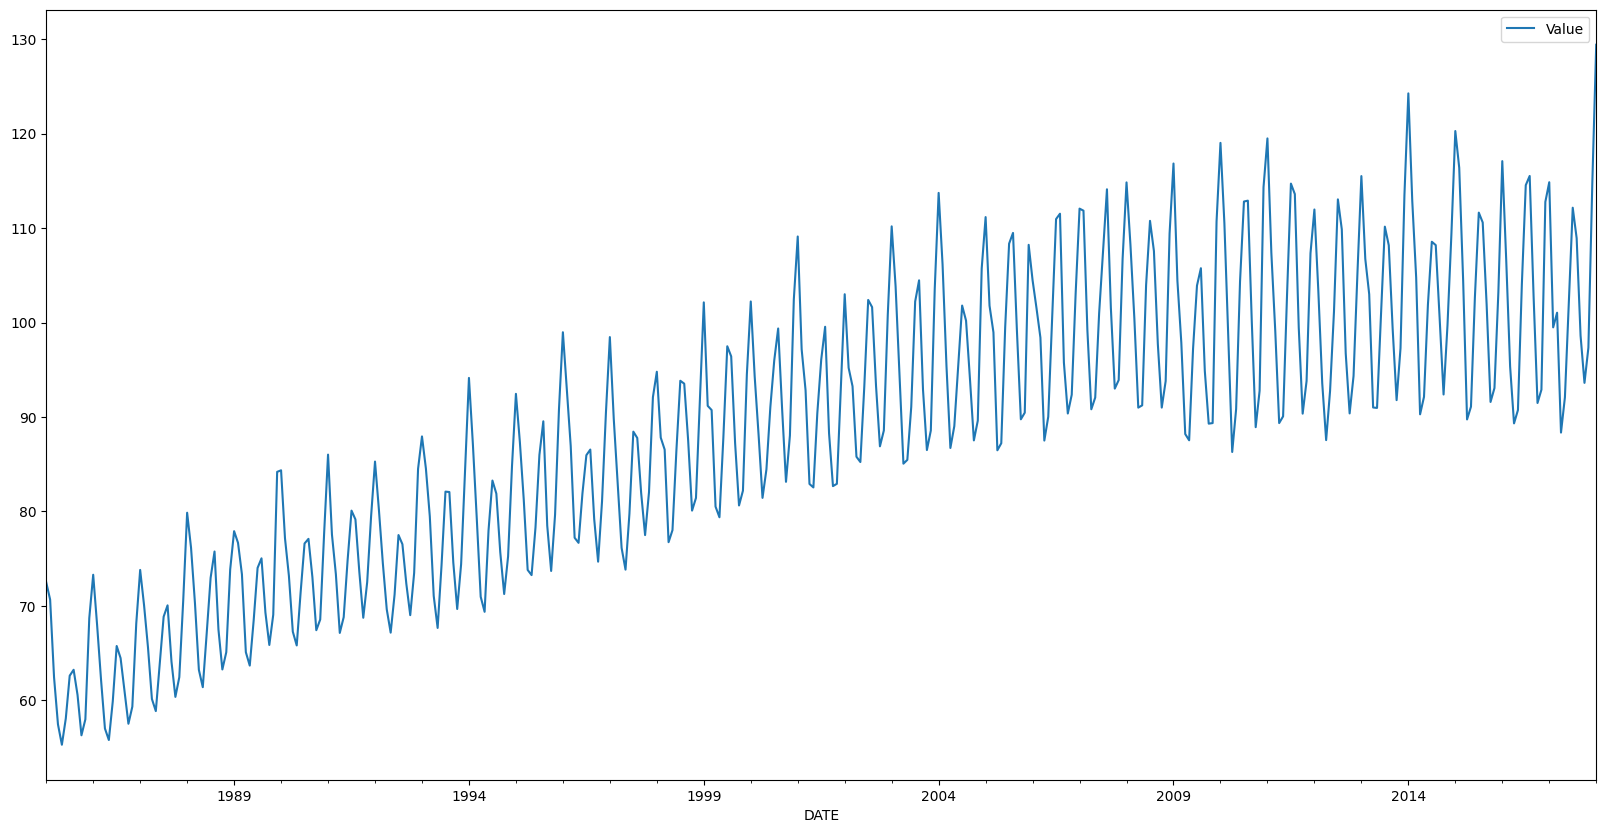

In [ ]:
# Checking for seasonality in our data
import matplotlib.pyplot as plt
data.plot()
plt.show()

In [40]:
# Filtering the date range
start_date = "1985-01-01"
end_date = "2010-01-01"
mask = (data.index >= start_date) & (data.index <= end_date)
data = data.loc[mask]

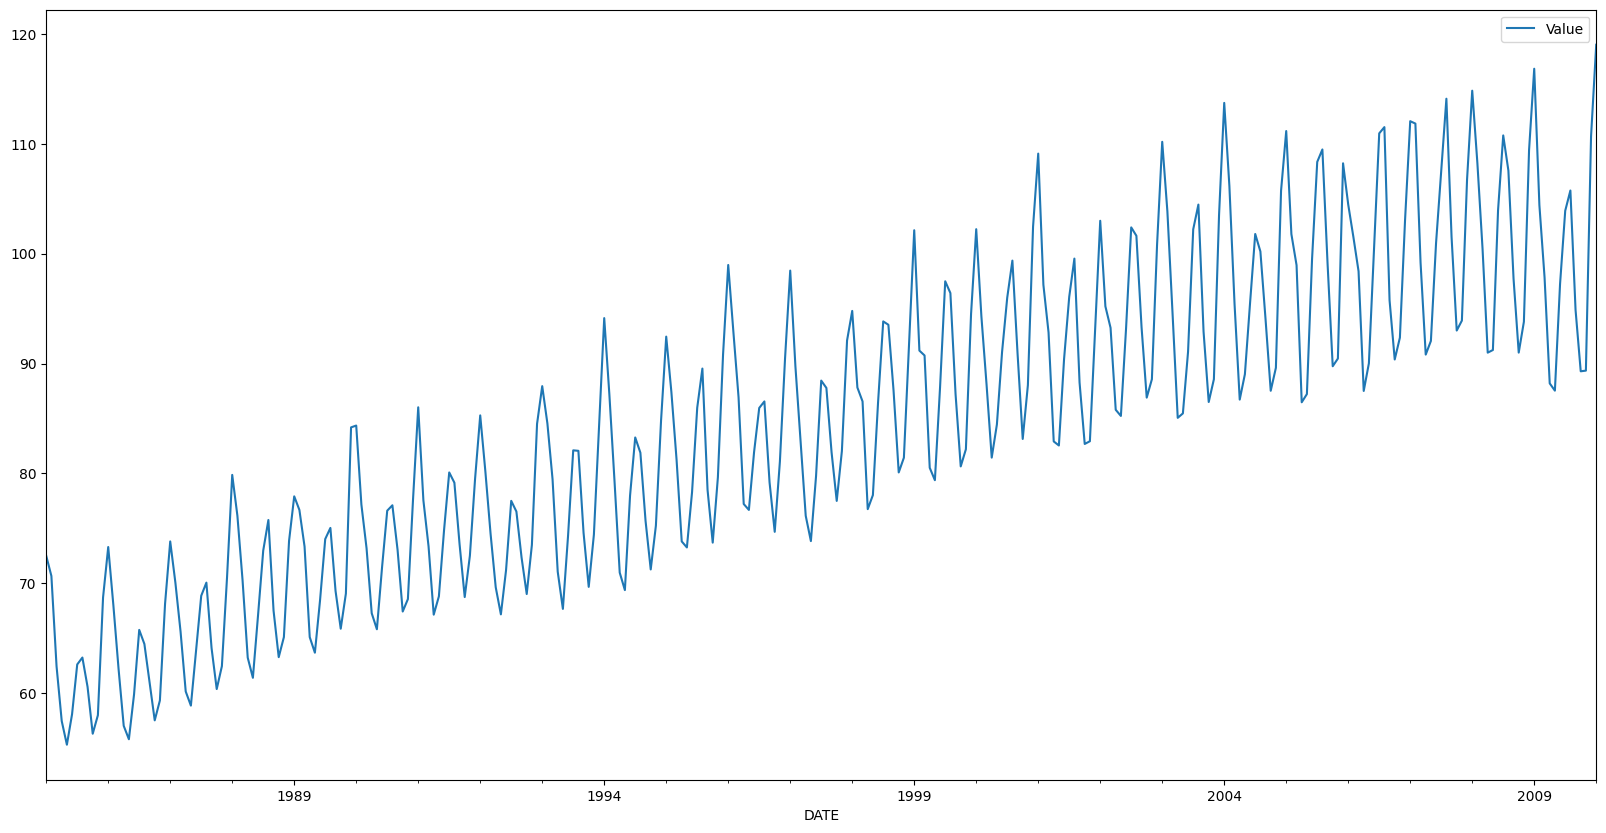

In [ ]:
data.plot()
plt.show()

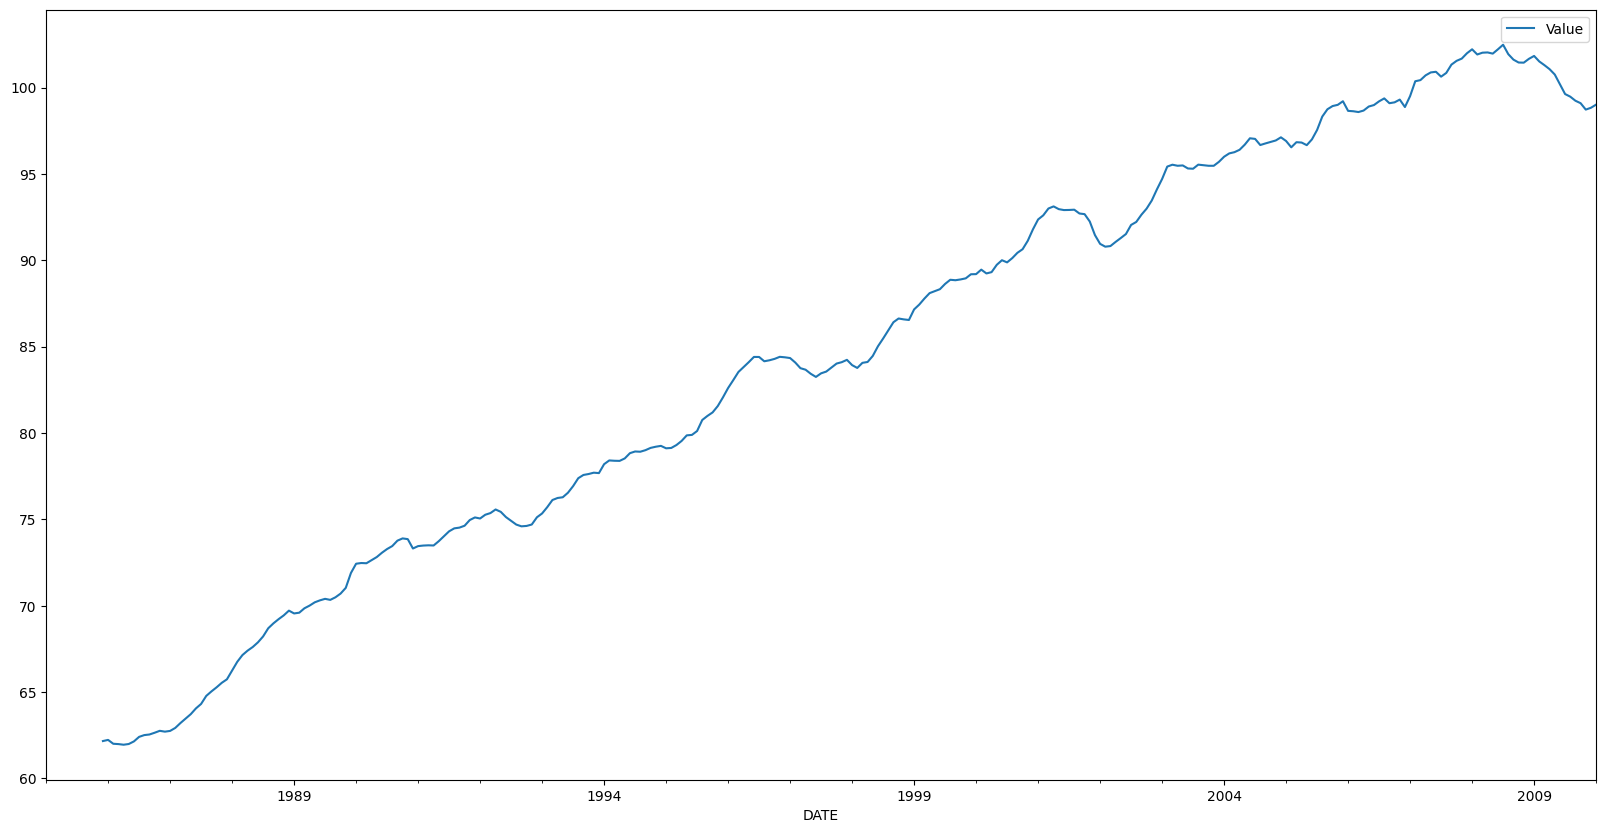

In [ ]:
# Ploting yearly averages
yearlydata = data.rolling(window=12).mean()
yearlydata.plot()
plt.show()

In [43]:
# Adding lines to graph to check seasonality better
xcoords = ["1986-01-01", "1987-01-01", "1988-01-01", "1989-01-01", "1990-01-01", "1991-01-01", "1992-01-01", "1993-01-01", "1994-01-01", "1995-01-01", "1996-01-01", "1997-01-01", "1998-01-01", "1999-01-01", "2000-01-01", "2001-01-01", "2002-01-01", "2003-01-01", "2004-01-01", "2005-01-01", "2006-01-01", "2007-01-01", "2008-01-01", "2009-01-01"]

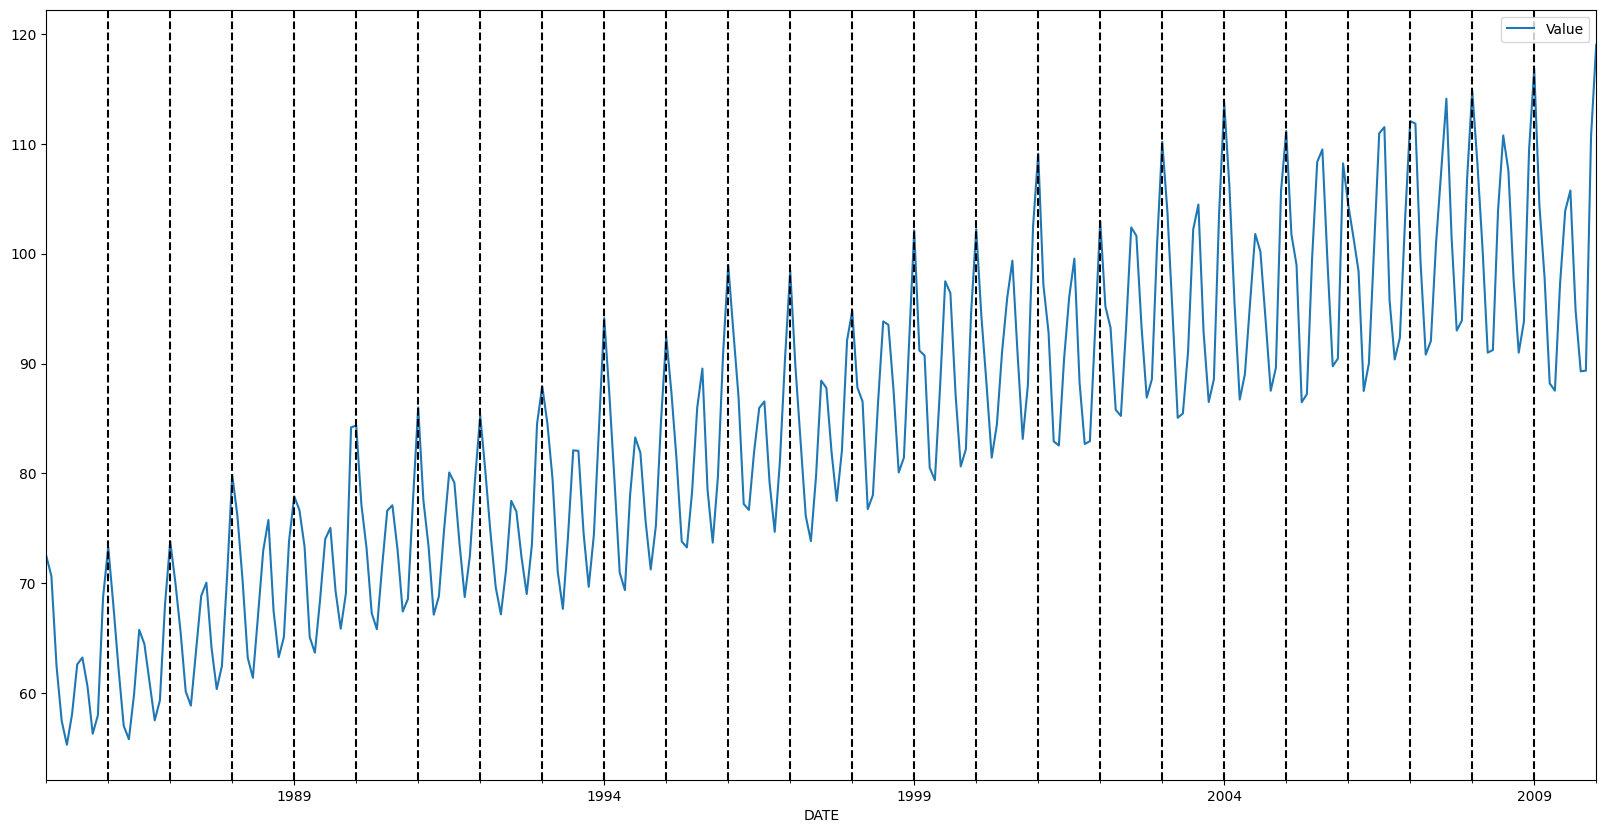

In [42]:
data.plot()
for xc in xcoords:
  plt.axvline(x=xc, color="black", linestyle= "--")
plt.show()

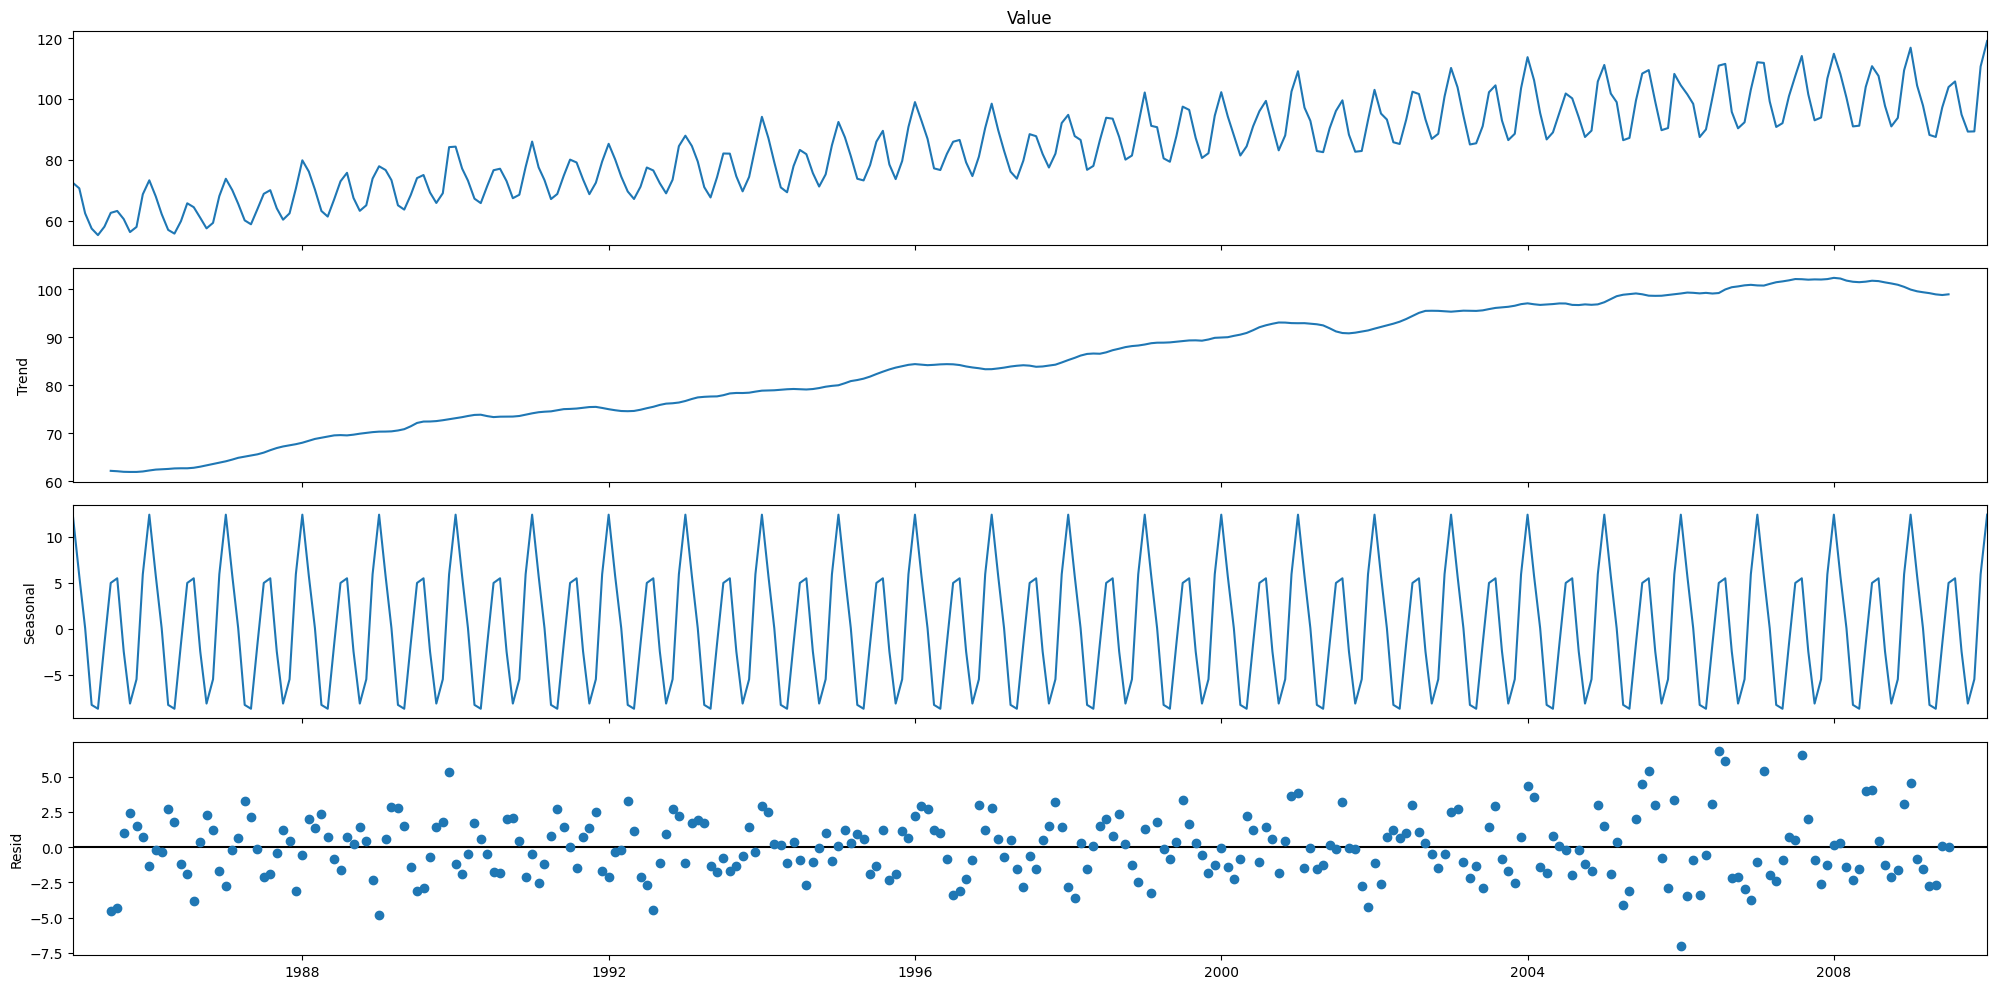

In [ ]:
# Using seasonal decomposition
from statsmodels.tsa.seasonal import seasonal_decompose
decomposed = seasonal_decompose(data["Value"], model="additive")
decomposed.plot()
plt.show()

In [44]:
# Defining function for Fuller's test for stationarity test in our data
from statsmodels.tsa.stattools import adfuller
def adf_test(series):
  result = adfuller((series), autolag = "AIC")
  labels = ["ADF Test Statistic", "p-value", "# lags", "# observations"]
  out = pd.Series(result[0:4], index=labels)
  print(out.to_string)
  if result[1] <= 0.05:
    print("Reject the null hypothesis")
    print("Data has no unit root and stationary")
  else:
    print("Fail to reject the null hypothesis")
    print("Data has a unit root and non-stationary")

In [ ]:
adf_test(data['Value'])

<bound method Series.to_string of ADF Test Statistic     -1.967267
p-value                 0.301107
# lags                 15.000000
# observations        285.000000
dtype: float64>
Fail to reject the null hypothesis
Data has a unit root and non-stationary


In [ ]:
# Training auto-regressive models
from statsmodels.tsa.ar_model import AutoReg
aic_score = []
for index in range(1,30):
  model = AutoReg(data['Value'], lags = index)
  model_fitted = model.fit()
  aic_score.append(model_fitted.aic)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

In [ ]:
aic_score.index(min(aic_score))

28

In [ ]:
aic_score[28]

np.float64(1278.0878377214342)

In [ ]:
model = AutoReg(data['Value'], lags = 28)
model_fitted = model.fit()
print(model_fitted.summary())

                            AutoReg Model Results                             
Dep. Variable:                  Value   No. Observations:                  301
Model:                    AutoReg(28)   Log Likelihood                -609.830
Method:               Conditional MLE   S.D. of innovations              2.259
Date:                Sun, 31 May 2026   AIC                           1279.660
Time:                        21:45:05   BIC                           1387.944
Sample:                    05-01-1987   HQIC                          1323.127
                         - 01-01-2010                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.9178      1.233      3.177      0.001       1.500       6.335
Value.L1       0.5588      0.061      9.232      0.000       0.440       0.677
Value.L2      -0.1033      0.069     -1.487      0.1

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [35]:
# Forecasting the next two years by adding 24 months into the data
fcast = model_fitted.predict(start = len(data), end = len(data) + 24)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


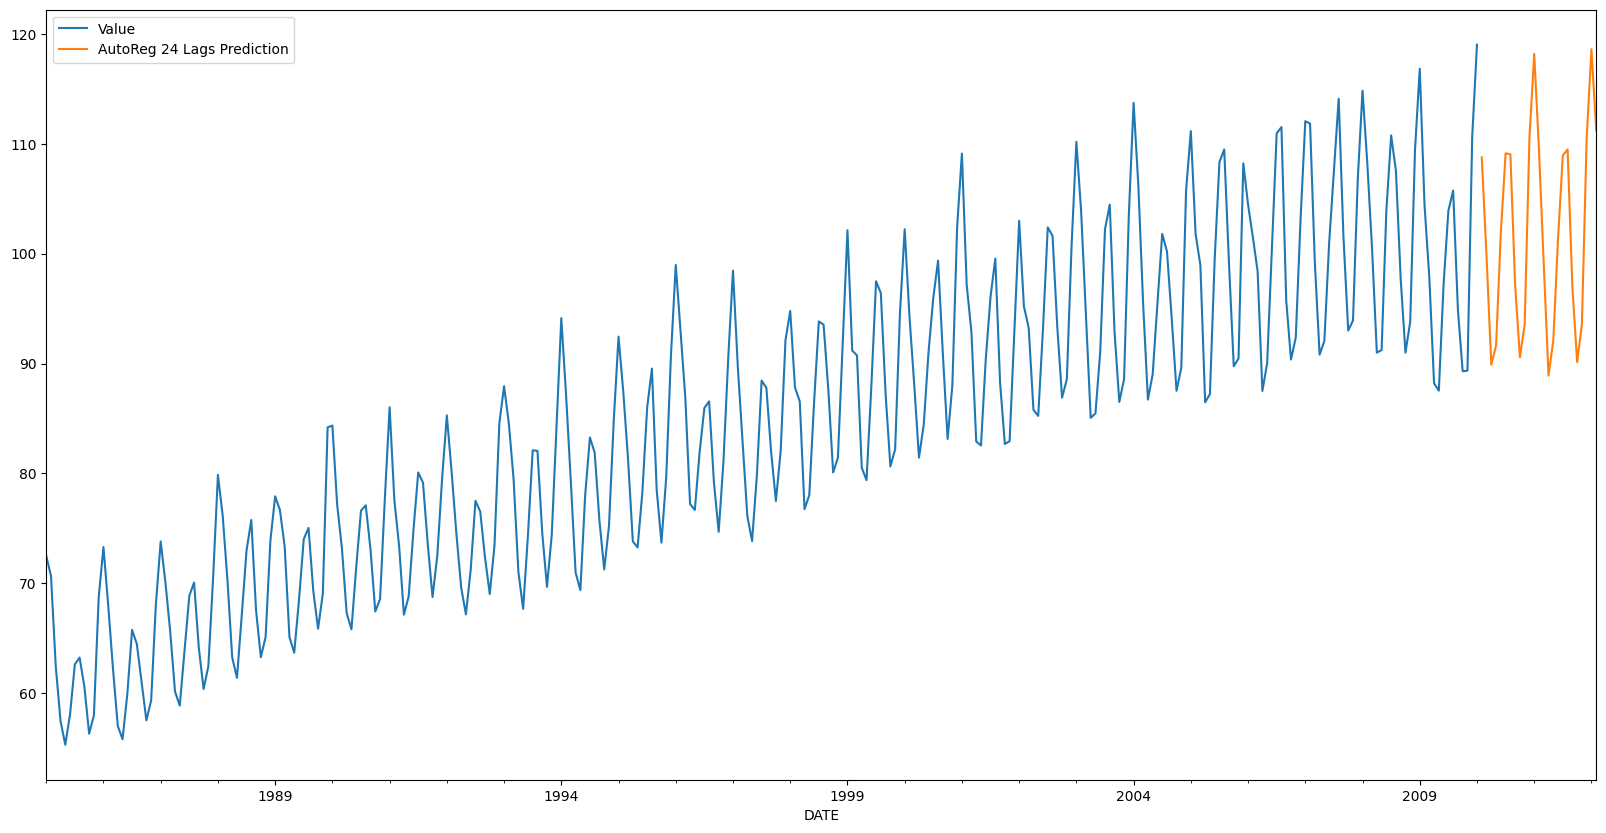

In [37]:
fcast = fcast.rename("AutoReg 24 Lags Prediction")
data.plot(legend=True)
fcast.plot(legend=True)
plt.show()